# 

In [138]:
import pyreadr
import numpy as np
import pandas as pd
import swifter
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
import scipy.stats as stats
from scipy.linalg import eigh
import pickle
from itertools import product


In [139]:
from fault_detection_algorithms.PCAFaultDetector import PCAFaultDetector
from fault_detection_algorithms.PLSFaultDetector import PLSFaultDetector 
from fault_detection_algorithms.PLSFaultDetectorImproved import PLSFaultDetectorImproved
from fault_detection_algorithms.fault_detector import BaseFaultDetectionAlgorithm 
from utils_ import plot_all_roc_curves, load_models_with_cache, train_models_with_cache, evaluate_models_with_cache, show_error_metrics_comparison
from cache_models import (
    train_with_cache, load_model_with_cache, evaluate_with_cache
)
from models_params import models_params

In [3]:
from fast_dataset_open import open_with_cache

In [4]:
import importlib
import fault_detection_algorithms.PCAFaultDetector
import fault_detection_algorithms.PLSFaultDetector
import fault_detection_algorithms.PLSFaultDetectorImproved
import fault_detection_algorithms.fault_detector
import utils_
import cache_models
import models_params

importlib.reload(fault_detection_algorithms.PCAFaultDetector)
importlib.reload(fault_detection_algorithms.PLSFaultDetector)
importlib.reload(fault_detection_algorithms.PLSFaultDetectorImproved)
importlib.reload(fault_detection_algorithms.fault_detector)
importlib.reload(utils_)
importlib.reload(cache_models)
importlib.reload(models_params)

from fault_detection_algorithms.PCAFaultDetector import PCAFaultDetector
from fault_detection_algorithms.PLSFaultDetector import PLSFaultDetector
from fault_detection_algorithms.PLSFaultDetectorImproved import PLSFaultDetectorImproved
from fault_detection_algorithms.fault_detector import BaseFaultDetectionAlgorithm
from utils_ import plot_all_roc_curves, load_models_with_cache, train_models_with_cache, evaluate_models_with_cache, show_error_metrics_comparison
from cache_models import (
    train_with_cache, load_model_with_cache, evaluate_with_cache
)
from models_params import models_params


In [5]:
# constants
datasets_dir = "datasets"
dataset_dir = f"./{datasets_dir}/TEP/"

In [6]:
X_columns= [ 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']

In [7]:
test_df = open_with_cache(f"{dataset_dir}/TEP_Faulty_Testing.RData", f"{dataset_dir}/TEP_FaultFree_Testing.RData")

Loading from cache: cache_data/38ed105d1e51ef36e954d9df89414b6e.pkl


In [127]:
def plot_generator(fault_idv, xmeas, extra_info, show_fault_time):
    xmeas_idx = xmeas-1
    df = test_df[(test_df["faultNumber"]==fault_idv)&(test_df["simulationRun"]==1)]
    df_no_fault = test_df[(test_df["faultNumber"]==0)&(test_df["simulationRun"]==1)]
    X = df["sample"].values
    Y = df[X_columns].values
    Y_ok = df_no_fault[X_columns].values
    #Y = (Y-Y.mean(axis=0))/Y.std(axis=0)
    start = xmeas_idx
    end = start+1
    end = min(end, len(X_columns))
    for i in range(start, end):
        yi = Y [:, i]
        yi_ok = Y_ok [:, i]
        min_ = min(np.min(yi), np.min(yi_ok))
        max_ = max(np.max(yi), np.max(yi_ok))
        fault_time = 160
        plt.plot(X, yi_ok,label= "Normal", linewidth=1)
        plt.plot(X, yi,label= "Faulty", linewidth=1)
        if show_fault_time:
            plt.plot((fault_time, fault_time), (min_,max_), '--',label= "Disturbance application",  )
    plt.xlabel("Timestamp")
    plt.ylabel(f"XMEAS({xmeas}) value")
    plt.legend()
    plt.title(f"{extra_info}  IDV({fault_idv})")
    plt.show()
        
        

In [ ]:

plots_params = [
    # fault_idv, xmeas, extra_info, show_fault_time
   (1,1,"Sudden change", True) ,
   (8,1,"Abnormal oscillations", True) ,
   (3,20,"Controllable", True) ,
   (4,9,"Back-to-Control", False) ,
] 
for params in plots_params:
    plot_generator(*params)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


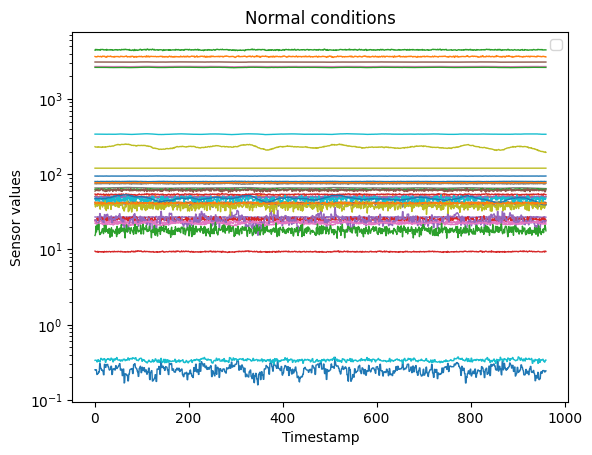

In [132]:
fault_idv = 1
xmeas_idx = 0
df = test_df[(test_df["faultNumber"]==fault_idv)&(test_df["simulationRun"]==1)]
df_no_fault = test_df[(test_df["faultNumber"]==0)&(test_df["simulationRun"]==1)]
X = df["sample"].values
Y = df[X_columns].values
Y_ok = df_no_fault[X_columns].values
#Y = (Y-Y.mean(axis=0))/Y.std(axis=0)
start = xmeas_idx
end = 1000
end = min(end, len(X_columns))
for i in range(start, end):
    yi = Y [:, i]
    yi_ok = Y_ok [:, i]
    min_ = min(np.min(yi), np.min(yi_ok))
    max_ = max(np.max(yi), np.max(yi_ok))
    fault_time = 160
    #plt.plot(X, yi_ok,label= "Normal", linewidth=1)
    plt.plot(X, yi_ok, linewidth=1)
    #plt.plot(X, yi,label= "Faulty", linewidth=1)
    if show_fault_time:
        plt.plot((fault_time, fault_time), (min_,max_), '--',label= "Disturbance application",  )
plt.xlabel("Timestamp")
plt.ylabel(f"Sensor values")
plt.yscale(f"log")
plt.legend()
plt.title(f"Normal conditions")
plt.show()

In [101]:
x_test = test_df[X_columns].values

In [9]:
expected_fault = test_df["sample"]>160
expected_fault[test_df["faultNumber"]==0] = False# non faulty test



In [367]:
models = load_models_with_cache(models_params)

[load_model_with_cache] Found model: model_cache/model_de30c44d6e409515a7dcc8dec1fdac97.pkl
[load_model_with_cache] Found model: model_cache/model_7f99f07f5397b87dc815aaefe27cf5e8.pkl
[load_model_with_cache] Found model: model_cache/model_44ed042d804cdf59f5ec4310bde63411.pkl
[load_model_with_cache] Found model: model_cache/model_fcafeba2e8cd62c8684fdde7a2572fcc.pkl
[load_model_with_cache] Found model: model_cache/model_d9ef42d6adfd9243357b4dddae8c5ac3.pkl


In [335]:
# models.pop("pca", None)
# models.pop("pca_r_scl", None)
models.keys()

dict_keys(['pca_r_scl', 'plsi LVs(6)', 'plsi LVs(29)', 'plsi LVs(6) percentiles', 'plsi LVs(29) percentiles'])

In [352]:
eval_params = {'roc_curve': True, 'by_fault_type': True}
#recompute = ['pca', 'pca_r_scl', 'pls LVs(6)', 'pls LVs(29)']
#recompute = []
#recompute = ["plsi LVs(6)", "plsi LVs(29)"]
#recompute = ["pls LVs(17)"]
#recompute = ["pca", "pca_r_scl", "pls LVs(6)"]
#recompute = ['plsi LVs(6) percentiles', 'plsi LVs(29) percentiles']
#recompute = ['plsi LVs(6)', 'plsi LVs(29)','plsi LVs(6) percentiles', 'plsi LVs(29) percentiles']
recompute = ['plsi LVs(29) percentiles']
#recompute = list(models.keys())

In [353]:
results = evaluate_models_with_cache(models, eval_params, x_test, expected_fault, test_df["faultNumber"], "tep_test", recompute=recompute)

[evaluate_with_cache] Loading evaluation results from model_cache/eval_4b16305a216455e9eb404e1cc68bdb59.pkl
[evaluate_with_cache] Loading evaluation results from model_cache/eval_43776448cc710ee2d72c75c86d0ee8b5.pkl
[evaluate_with_cache] Loading evaluation results from model_cache/eval_38a5117d13c3fe889bf6bc34c99df8aa.pkl
[evaluate_with_cache] Loading evaluation results from model_cache/eval_6cd42c4fd315927e7dcc9f1bfc7bd932.pkl
[evaluate_with_cache] Computing evaluation results...


/home/usuario/GhentInternship/fault_detection_algorithms/fault_detector.py:148: RuntimeWarning: invalid value encountered in scalar divide
  "Fault Detection Rate": TP / (TP + FN),


spe_thresholds 2.191365628723773 192.91837784279264
spe_thresholds 0 192.91837784279264


/home/usuario/GhentInternship/fault_detection_algorithms/fault_detector.py:149: RuntimeWarning: invalid value encountered in scalar divide
  "False Detection Rate": FP / (TP + FP),


spe_thresholds 7.368477001921566 163.61211698681123
spe_thresholds 4.259327657891961 163.61211698681123
spe_thresholds 2.191365628723773 163.61211698681123
spe_thresholds 20.84350745877517 163.61211698681123
spe_thresholds 4.939859421922376 163.61211698681123
spe_thresholds 78.14747746391669 163.61211698681123
spe_thresholds 64.63325693516812 163.61211698681123
spe_thresholds 4.143632679737657 163.61211698681123
spe_thresholds 2.581060325877769 163.61211698681123
spe_thresholds 3.6988362246156425 163.61211698681123
spe_thresholds 3.3461244899332874 163.61211698681123
spe_thresholds 4.143632679737657 163.61211698681123
spe_thresholds 4.143632679737657 163.61211698681123
spe_thresholds 9.404665240387807 163.61211698681123
spe_thresholds 2.3279858299393728 163.61211698681123
spe_thresholds 3.924767217730309 163.61211698681123
spe_thresholds 4.143632679737657 163.61211698681123
spe_thresholds 3.816037547123618 163.61211698681123
spe_thresholds 4.272752549102968 163.61211698681123
spe_thres

In [317]:

ordering = [0, 1,2,4,5,6,7,8,12,13,14,17,18,10,11,16,19,20, 3,9,15, -1 ]
#ordering = [0, 8, 9,10, 11, 12, 13, 1,2,4,6,7,17,18,20,3,5,14,15,16,19]

In [320]:
show_error_metrics_comparison(results, ordering, fault_error_metrics=["Fault Detection Rate", "False Detection Rate"] )


Fault Detection Rate


,pca_r_scl,plsi LVs(6),plsi LVs(29),plsi LVs(6) percentiles,plsi LVs(29) percentiles
IDV(1),0.998060,0.997395,1.0,0.997360,1.0
IDV(2),0.984507,0.986067,1.0,0.985988,1.0
IDV(4),0.999890,0.986117,1.0,0.983470,1.0
IDV(5),1.000000,0.321308,1.0,0.317870,1.0
IDV(6),1.000000,1.000000,1.0,1.000000,1.0
IDV(7),1.000000,1.000000,1.0,1.000000,1.0
IDV(8),0.977603,0.975073,1.0,0.974938,1.0
IDV(12),0.992925,0.988280,1.0,0.988173,1.0
IDV(13),0.948778,0.948107,1.0,0.947950,1.0
IDV(14),0.999680,0.999537,1.0,0.999522,1.0



False Detection Rate


,pca_r_scl,plsi LVs(6),plsi LVs(29),plsi LVs(6) percentiles,plsi LVs(29) percentiles
IDV(1),0.002785,0.007157,0.166667,0.006871,0.166667
IDV(2),0.002823,0.007239,0.166667,0.006949,0.166667
IDV(4),0.002780,0.007238,0.166667,0.006967,0.166667
IDV(5),0.002780,0.021888,0.166667,0.021246,0.166667
IDV(6),0.002780,0.007139,0.166667,0.006853,0.166667
IDV(7),0.002780,0.007139,0.166667,0.006853,0.166667
IDV(8),0.002843,0.007320,0.166667,0.007028,0.166667
IDV(12),0.002800,0.007223,0.166667,0.006934,0.166667
IDV(13),0.002929,0.007526,0.166667,0.007226,0.166667
IDV(14),0.002781,0.007142,0.166667,0.006856,0.166667



False Alarm Rate


,pca_r_scl,plsi LVs(6),plsi LVs(29),plsi LVs(6) percentiles,plsi LVs(29) percentiles
IDV(0),0.020944,0.056656,1.0,0.054929,1.0


In [295]:
results["plsi LVs(29) percentiles"]["roc_data"]["by_fault"] [11]

{'Fault Detection Rate': [1.0,
  0.999875,
  0.99982,
  0.999805,
  0.999775,
  0.99976,
  0.9997375,
  0.9997175,
  0.9997,
  0.9996825,
  0.999675,
  0.9996675,
  0.99966,
  0.9996375,
  0.9996175,
  0.9995925,
  0.9995725,
  0.999555,
  0.9995425,
  0.9995275,
  0.999515,
  0.999505,
  0.9994975,
  0.999485,
  0.9994675,
  0.9994525,
  0.9994275,
  0.9994175,
  0.99939,
  0.999375,
  0.9993575,
  0.99934,
  0.9993175,
  0.9993075,
  0.999295,
  0.999285,
  0.9992675,
  0.99925,
  0.9992325,
  0.9992175,
  0.9992025,
  0.9991875,
  0.999175,
  0.999165,
  0.9991375,
  0.99911,
  0.999105,
  0.9990925,
  0.9990775,
  0.99906,
  0.9990425,
  0.9990275,
  0.9990125,
  0.9989825,
  0.99897,
  0.9989325,
  0.9989,
  0.99887,
  0.9988475,
  0.9988175,
  0.9988,
  0.99877,
  0.9987525,
  0.9987025,
  0.9986725,
  0.9986225,
  0.9985875,
  0.9985675,
  0.9985325,
  0.9985025,
  0.998465,
  0.99843,
  0.9984075,
  0.99837,
  0.998325,
  0.9982775,
  0.9982325,
  0.99818,
  0.9981325,
  0.9980

In [ ]:
#plot_models=["pls LVs(6)", "pls LVs(29)", "pls LVs(17)"]
#plot_models=["pls LVs(29)", "plsi LVs(29)", "pls LVs(17)"]
#plot_models=["plsi LVs(29)", "pca_r_scl", "plsi LVs(6)"]
# plot_models=["plsi LVs(6)", "plsi LVs(29)"]
#plot_models=[ "plsi LVs(29)"]
#plot_models=["plsi LVs(6)", "plsi LVs(6) percentiles"]
plot_models=["plsi LVs(29) percentiles"]
#plot_models=["pca_r_scl"]
plot_all_roc_curves(results,plot_models=plot_models,   scatter=True, show_identity=False, scatter_size = 1)

In [368]:
model = models["plsi LVs(29) percentiles"]


In [370]:
models["plsi LVs(29)"].SPE_threshold_

0.024045107626331556

In [369]:
#model.roc_parametrers_range()
model.SPE_threshold_

0.024320029678892997

In [357]:
indicators = model.compute_indicators(x_test)

In [358]:
indicators[0]

array([66.48926711, 35.48944982,  9.73785849, ..., 22.50219724,
       12.34971695, 31.10000899])

In [359]:
model.roc_parametrers_range(indicators, expected_fault, npoints=100)

spe_thresholds 2.191365628723773 192.91837784279264


array([[  1.53280153,   0.        ],
       [  7.77715136,  14.27543383],
       [  9.06612653,  15.59666296],
       [  9.9248501 ,  16.47831691],
       [ 10.61596789,  17.16421742],
       [ 11.19831036,  17.73671054],
       [ 11.72091924,  18.23440652],
       [ 12.21345359,  18.67874526],
       [ 12.66031599,  19.08295948],
       [ 13.07482475,  19.45583458],
       [ 13.48715955,  19.80352466],
       [ 13.8893128 ,  20.13052198],
       [ 14.22573417,  20.44021472],
       [ 14.57006676,  20.73522741],
       [ 14.91962489,  21.01763862],
       [ 15.24029794,  21.28912572],
       [ 15.55884896,  21.55106441],
       [ 15.88502371,  21.80459888],
       [ 16.20316581,  22.05069269],
       [ 16.51970373,  22.29016627],
       [ 16.82755921,  22.52372513],
       [ 17.13653508,  22.75198148],
       [ 17.44151443,  22.97547094],
       [ 17.73132387,  23.19466573],
       [ 18.02913459,  23.4099851 ],
       [ 18.31078693,  23.62180378],
       [ 18.58865326,  23.83045878],
 

In [347]:
np.percentile(indicators[0][np.bitwise_not(expected_fault)], np.linspace(0,1,100)*100)

array([  1.53280153,   7.77715136,   9.06612653,   9.9248501 ,
        10.61596789,  11.19831036,  11.72091924,  12.21345359,
        12.66031599,  13.07482475,  13.48715955,  13.8893128 ,
        14.22573417,  14.57006676,  14.91962489,  15.24029794,
        15.55884896,  15.88502371,  16.20316581,  16.51970373,
        16.82755921,  17.13653508,  17.44151443,  17.73132387,
        18.02913459,  18.31078693,  18.58865326,  18.87721885,
        19.16527506,  19.43846992,  19.72549255,  20.00842099,
        20.2889035 ,  20.57979164,  20.8762005 ,  21.14522222,
        21.42399388,  21.71687293,  21.99787382,  22.2825235 ,
        22.57452745,  22.86172952,  23.14799137,  23.4365123 ,
        23.73366914,  24.02771392,  24.32276397,  24.62920156,
        24.92471291,  25.2277802 ,  25.54199817,  25.88044984,
        26.21040022,  26.54992631,  26.8907171 ,  27.22599132,
        27.58768806,  27.93783356,  28.29000165,  28.66840849,
        29.0382994 ,  29.41672052,  29.79340432,  30.18

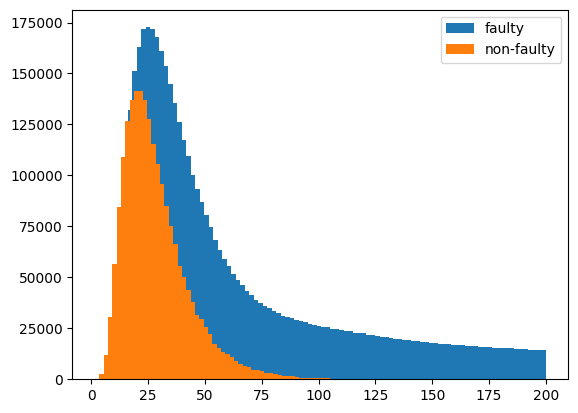

In [364]:
#plt.hist(indicators[0][indicators[0]<1000], bins=1000)
plt.hist(indicators[0][expected_fault & (indicators[0]<200)], bins=100, label="faulty",)
plt.hist(indicators[0][np.bitwise_not(expected_fault)  & (indicators[0]<200)], bins=100, label="non-faulty")
plt.legend()
plt.show()

In [365]:
indicators_ = np.array(indicators)


In [302]:
fault_id = 11

In [303]:
# faulty_X_ = indicators_[:, (expected_fault & (test_df["faultNumber"] == 1) & (test_df["simulationRun"] == 1)) ]
# nonfaulty_X_ = indicators_[:, (np.bitwise_not(expected_fault)) &(test_df["faultNumber"]==1 ) & (test_df["simulationRun"] ==1)]
faulty_X_ = indicators_[:, (expected_fault & (test_df["faultNumber"] == fault_id) ) ]
nonfaulty_X_ = indicators_[:, (np.bitwise_not(expected_fault) &(test_df["faultNumber"]==fault_id ) )]

faulty_selector = np.random.choice(faulty_X_.shape[1], 1000)
nonfaulty_selector = np.random.choice(nonfaulty_X_.shape[1], 1000)

faulty_X = faulty_X_[:,faulty_selector]

nonfaulty_X = nonfaulty_X_[:,nonfaulty_selector]

In [304]:
np.sum((test_df["faultNumber"] ==fault_id) & (test_df["sample"] == fault_id))

500

In [305]:
print(faulty_X_.shape)
print(nonfaulty_X_.shape)
print(faulty_X.shape)
print(nonfaulty_X.shape)

(2, 400000)
(2, 80000)
(2, 1000)
(2, 1000)


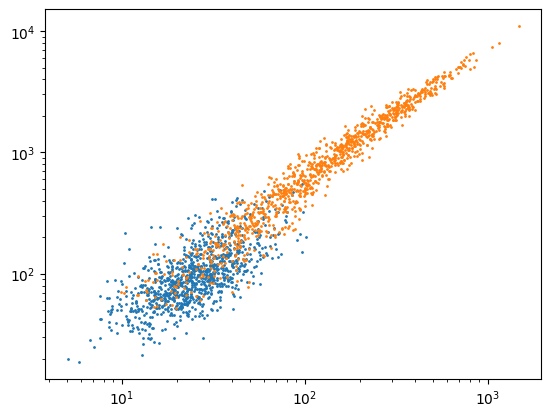

In [306]:
# plt.scatter(nonfaulty_X_[0], nonfaulty_X_[1], s=1)
# plt.scatter(faulty_X_[0], faulty_X_[1], s=1)
plt.scatter(nonfaulty_X[0], nonfaulty_X[1], s=1)
plt.scatter(faulty_X[0], faulty_X[1], s=1)
plt.yscale("log")
plt.xscale("log")

In [307]:
expected_fault.dtype

dtype('bool')

In [308]:
results["pca_r_scl"]["roc_data"]["by_fault"][fault_id]

{'Fault Detection Rate': [1.0,
  0.9999975,
  0.9999825,
  0.9999575,
  0.999925,
  0.9998775,
  0.999795,
  0.99971,
  0.99963,
  0.9995225,
  0.9994075,
  0.999255,
  0.9990875,
  0.9989125,
  0.9987275,
  0.998525,
  0.9982825,
  0.9980275,
  0.997755,
  0.9974725,
  0.99713,
  0.99674,
  0.996375,
  0.995975,
  0.9955625,
  0.995205,
  0.994715,
  0.9942525,
  0.9937475,
  0.9932225,
  0.9926425,
  0.99203,
  0.99138,
  0.9907075,
  0.99,
  0.9892875,
  0.9884675,
  0.9876225,
  0.9867975,
  0.9859525,
  0.9850775,
  0.9841675,
  0.9831425,
  0.9821775,
  0.981155,
  0.9799925,
  0.97883,
  0.977655,
  0.9763975,
  0.9750575,
  0.97372,
  0.9723625,
  0.9708825,
  0.9692825,
  0.96771,
  0.9661025,
  0.9643075,
  0.9627275,
  0.961015,
  0.95906,
  0.9570975,
  0.9549575,
  0.9528725,
  0.950705,
  0.94838,
  0.945945,
  0.94351,
  0.941155,
  0.9384025,
  0.93575,
  0.9327625,
  0.92983,
  0.927005,
  0.92382,
  0.920735,
  0.9174475,
  0.91409,
  0.910465,
  0.9066875,
  0.902937

In [309]:
# roc_range = model.roc_parametrers_range()
# print(roc_range[-1], roc_range[0])

In [310]:
inds_timeline = indicators_[:, ( (test_df["faultNumber"] == fault_id) ) ]
#inds_timeline = indicators_[:, ( (test_df["faultNumber"] == 1) & (test_df["simulationRun"] == 1)) ]
timestamp = test_df["sample"][test_df["faultNumber"] ==fault_id]
simrun= test_df["simulationRun"][test_df["faultNumber"] ==fault_id]
inds_timeline.shape

(2, 480000)

In [311]:
timestamp.shape

(480000,)

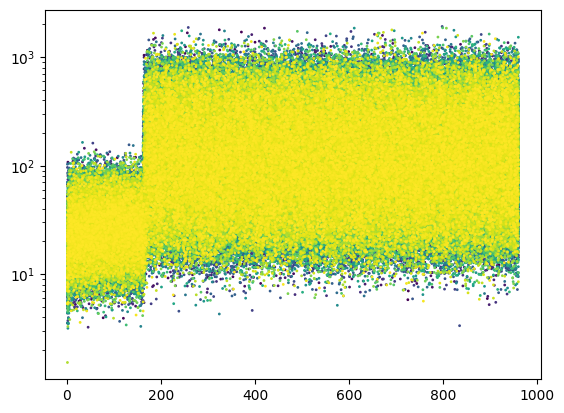

In [313]:
plt.scatter(timestamp, inds_timeline[0], c=simrun, s = 1)
plt.yscale("log")

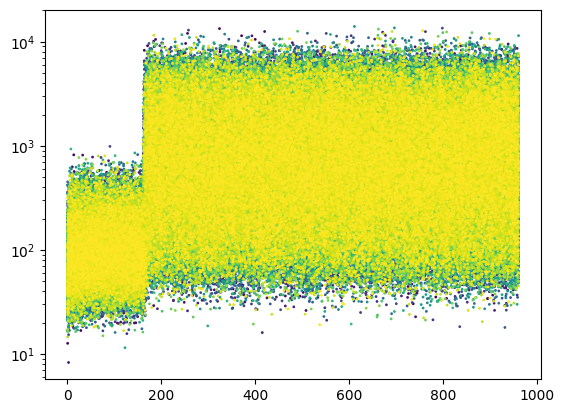

In [314]:
plt.scatter(timestamp, inds_timeline[1], c=simrun, s = 1)
plt.yscale("log")

In [259]:
model.SPE_threshold_

0.024045107626331556

In [260]:
model.T2_threshold_

49.59587803559938